In [1]:
from math import degrees
import numpy as np;
import pandas as pd;
from sklearn.model_selection import train_test_split;
from sklearn import linear_model;
from sklearn.preprocessing import PolynomialFeatures, StandardScaler;
from matplotlib import pyplot as plt;

# Data Points
P = 100

# Take the input
x_input = np.linspace(-3, 3, P) # fixed: was linspace(3,3,P) -> every point identical, no variation to regress on

# 2nd order Polynomial
y_output = 7**x_input + 8*x_input + 6; # ---- 786 :D

# Can I take a Gaussion noise, cause we like more tangent rather than a straight line. BTW I am straight :XD
np.random.seed(42) # PGCI Generator. just to set the randomness at 42 (best value)
noise = np.random.normal(0, 1, len(y_output)) # --- 3D.

# Actual Output
y_actual_output = y_output + noise;

#Another Mat of manual Transpose to use rather than PolynomialFeatures func from sklearn
x_input_tran = np.transpose([x_input])
y_actual_output_tran = np.transpose([y_actual_output])

# Data Splitting (Train = x, Test = y)
x_train, x_test, y_train, y_test = (train_test_split(x_input_tran, y_actual_output, test_size = 0.2, random_state =42))

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Change the Shape of the Mat. of train and test of Trainning Data (x) Cause learn Polynomial Func is 2D
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

# Just for simplicity, make another small py func of polynomial features eqn
def get_poly_features(X, degreeInput):
    poly = PolynomialFeatures(degree = degreeInput, include_bias=False)
    return poly.fit_transform(X)
# Root Mean Squre Error from actual to oringinal difference -- y_actual = y_pred - y_real -- root mean square np.sqrt(np.sum(y ** 2 / len(y)))
def RMSE(y_pred,y_real):
  y_actual = y_pred - y_real
  rms_y=np.sqrt(np.sum((y_actual)**2)/len(y_actual))
  return rms_y


x_train shape: (80, 1)
x_test shape: (20, 1)
y_train shape: (80,)
y_test shape: (20,)


In [2]:
x_train_manual = x_train.copy()
x_test_manual = x_test.copy()

degrees=20
for i in range(degrees - 1):
    power = i + 2
    x_train_manual = np.concatenate((x_train_manual, x_train ** power), axis=1)
    x_test_manual = np.concatenate((x_test_manual, x_test ** power), axis=1)

x_train_sklearn_poly = get_poly_features(x_train, degrees)
x_test_sklearn_poly = get_poly_features(x_test, degrees)

# Print to show manual Polynomial Function
scaler = StandardScaler()
x_train_manual_scaled = scaler.fit_transform(x_train_manual)
x_test_manual_scaled = scaler.transform(x_test_manual)

scaler = StandardScaler()
x_train_sklearn_poly_scaled = scaler.fit_transform(x_train_sklearn_poly)
x_test_sklearn_poly_scaled = scaler.transform(x_test_sklearn_poly)

In [3]:
# Linear regression fit on sklearn polynomial function
sklearn_model = linear_model.LinearRegression()
sklearn_model.fit(x_train_sklearn_poly_scaled, y_train)
y_pred = sklearn_model.predict(x_test_sklearn_poly_scaled)


#linear regression fit on manual Polynomial Function
manual_model = linear_model.LinearRegression()
manual_model.fit(x_train_manual_scaled, y_train)
y_pred_scaled = manual_model.predict(x_test_manual_scaled)

# Root Mean Square Error
rmse = RMSE(y_pred, y_test)
rmse_scaled = RMSE(y_pred_scaled, y_test)

print(f" Root Mean Squared Error (RMSE) on the test data (Sklearn.PolyNomialFeatures): {rmse}")
print(f" Root Mean Squared Error (RMSE) on the test data (Manual or yoouuu (set by User)): {rmse_scaled}")

 Root Mean Squared Error (RMSE) on the test data (Sklearn.PolyNomialFeatures): 2.00165070535518
 Root Mean Squared Error (RMSE) on the test data (Manual or yoouuu (set by User)): 2.00165070534587


In [4]:
alpha_list_manual = (np.linspace(0.1,5,10000))  # ---- 3D
alpha_list_sklearn = (np.linspace(0.1,5,10000))  # ---- 3D

list_of_rmse_manual = []
list_of_rmse_sklearn = []

for alpha in alpha_list_manual:
    
    lasso_model = linear_model.Lasso(alpha=alpha, fit_intercept=True, max_iter=100000)
    lasso_model.fit(x_train_manual_scaled, y_train)
    y_pred_lasso = lasso_model.predict(x_test_manual_scaled)

    rmse_manual = RMSE(y_pred_lasso, y_test)

    list_of_rmse_manual.append(rmse_manual)

for alpha in alpha_list_sklearn:

    lasso_model = linear_model.Lasso(alpha=alpha, fit_intercept=True, max_iter=100000)
    lasso_model.fit(x_train_sklearn_poly_scaled, y_train)
    y_pred_lasso = lasso_model.predict(x_test_sklearn_poly_scaled)

    rmse_sklearn = RMSE(y_pred_lasso,y_test)

    list_of_rmse_sklearn.append(rmse_sklearn)

print("List of RMSE Manual size :: {} \nList of RMSE SKLEARN size :: {}".format(len(list_of_rmse_manual), len(list_of_rmse_sklearn)))

List of RMSE Manual size :: 10000 
List of RMSE SKLEARN size :: 10000


In [5]:
given_alpha = 0.0001

lasso_rag_manual = linear_model.Lasso(alpha=given_alpha, fit_intercept=True, max_iter=100000)
lasso_rag_manual.fit(x_train_manual_scaled,y_train)
y_pred_lasso_manual = lasso_rag_manual.predict(x_test_manual_scaled)

lasso_rag_sklearn = linear_model.Lasso(alpha=given_alpha, fit_intercept=True, max_iter=100000)
lasso_rag_sklearn.fit(x_train_sklearn_poly_scaled, y_train)  # fixed: was fit on unscaled features, inconsistent with manual model
y_pred_lasso_sklearn = lasso_rag_sklearn.predict(x_test_sklearn_poly_scaled)

rmse_lasso_manual = RMSE(y_pred_lasso_manual, y_test)

rmse_lasso_sklearn = RMSE(y_pred_lasso_sklearn, y_test)

print(
    f"When alpha = {given_alpha}, "
    f"Manual Lasso RMSE = {rmse_lasso_manual:.6f}"
)

print(
    f"When alpha = {given_alpha}, "
    f"Sklearn Lasso RMSE = {rmse_lasso_sklearn:.6f}"
)

When alpha = 0.0001, Manual Lasso RMSE = 1.036136
When alpha = 0.0001, Sklearn Lasso RMSE = 1.036136


In [6]:
minimum_index_manual = np.argmin(list_of_rmse_manual)
alpha_min_manual = alpha_list_manual[minimum_index_manual]
min_rmse_manual = list_of_rmse_manual[minimum_index_manual]
print(
    f"Manual: Minimum RMSE = {min_rmse_manual:.6f} "
    f"at Alpha = {alpha_min_manual:.6f}"
)

minimum_index_sklearn = np.argmin(list_of_rmse_sklearn)
alpha_min_sklearn = alpha_list_sklearn[minimum_index_sklearn]
min_rmse_sklearn = list_of_rmse_sklearn[minimum_index_sklearn]
print(
    f"Sklearn: Minimum RMSE = {min_rmse_sklearn:.6f} "
    f"at Alpha = {alpha_min_sklearn:.6f}"
)

Manual: Minimum RMSE = 0.871908 at Alpha = 0.100000
Sklearn: Minimum RMSE = 0.871908 at Alpha = 0.100000


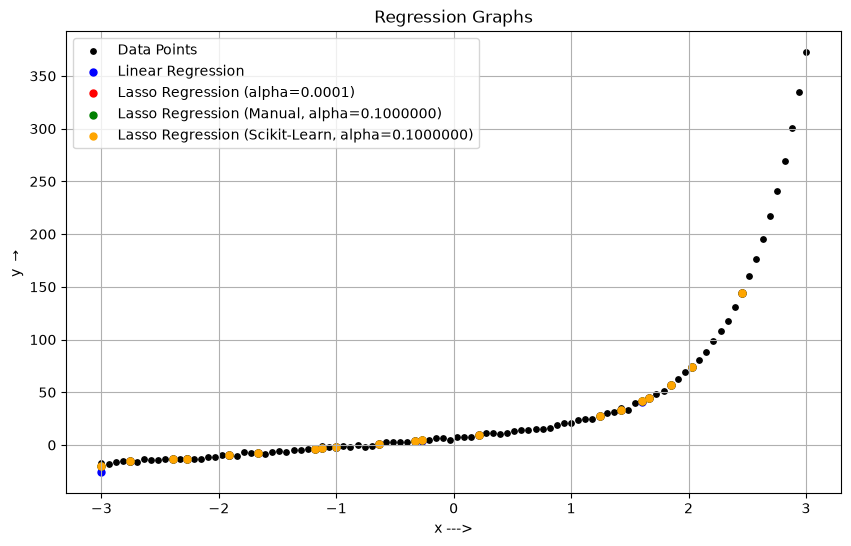

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(x_input, y_actual_output, color="black", s=15)
plt.scatter(x_test, y_pred, color="blue", s=25)
plt.scatter(x_test, y_pred_lasso_sklearn, color="red", s=25)  # fixed: was stale y_pred_lasso left over from the cell-3 alpha sweep, not the given_alpha fit
plt.scatter(x_test, y_pred_lasso_manual, color="green", s=25)
plt.scatter(x_test, y_pred_lasso_sklearn, color="orange", s=25)


plt.xlabel("x --->")
plt.ylabel(r"y $\rightarrow$")

plt.title("Regression Graphs")

plt.legend(
    [
        "Data Points",
        "Linear Regression",
        f"Lasso Regression (alpha={given_alpha})",
        f"Lasso Regression (Manual, alpha={alpha_min_manual:.7f})",
        f"Lasso Regression (Scikit-Learn, alpha={alpha_min_sklearn:.7f})"
    ]
)

plt.grid()
plt.show()